In [9]:
import pandas as pd
import numpy as np
from IPython import display
from pyecharts.charts import Bar, Page, Pie, WordCloud
from pyecharts import options as opts
import re
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 设置 matplotlib 的字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 指定默认字体为黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决保存图像时符号'-'显示为方块的问题

In [10]:
data=pd.read_csv('../data/job.csv')
data.head()

,职位名称,薪资范围,地点,工作经验,学历要求,岗位标签,公司名称,公司类型,公司规模,city
0,销售数据分析,1.2万-1.8万,上海,3-5年,本科,"['IT/互联网', 'Java', 'Python', 'SPSS', 'SAS', 'S...",云竞(上海)电子科技有限公司,民营,500-999人,上海
1,金融数据分析师,1.6万-1.8万,上海-黄浦,3-5年,本科,"['银行数据分析', '投融资数据分析', 'SQL', 'Python', '决策树']",北京戌华防务技术有限公司,民营,100-299人,上海
2,酒店财务数据分析,1.2万-1.5万,上海,3-5年,本科,['Power BI'],上海锦江国际酒店股份有限公司第一分公司,国企,100-299人,上海
3,数据分析经理,1.5万-1.8万,上海-徐汇,5-10年,本科,"['SQL', 'R', '数学/统计学专业', '线下零售', '餐饮业']",达美乐比萨,外商独资,500-999人,上海
4,IT校招-数据分析师(J13446),1万-2万,上海-青浦,不限,本科,"['Python', 'Tableau', '运营数据分析']",中通快递,股份制企业,10000人以上,上海


In [11]:
data.shape

(6685, 10)

In [12]:
#检查缺失值
missing_values = data.isnull().sum()
data = data.dropna(axis=0)
#检查重复值
duplicate_rows = data.duplicated().sum()
data = data.drop_duplicates()
data.shape

(6611, 10)

In [13]:
# 定义一个函数来转换薪资范围
def convert_salary_range(salary_str):
    # 使用正则表达式提取数字和单位
    pattern = re.compile(r'([\d.]+)(千|万)?-([\d.]+)(千|万)?')
    match = pattern.match(salary_str)

    # 如果匹配失败，返回 NaN 值
    if match is None:
        return pd.Series([np.nan, np.nan], index=['最低薪资', '最高薪资'])

    # 提取匹配的组
    lower, lower_unit, upper, upper_unit = match.groups()

    # 转换为数值
    lower = float(lower) * 1000 if lower_unit == '千' else float(lower) * 10000
    upper = float(upper) * 1000 if upper_unit == '千' else float(upper) * 10000

    return pd.Series([lower, upper], index=['最低薪资', '最高薪资'])

# 使用函数转换 "薪资范围" 列，并将计算出的最低薪资和最高薪资添加到数据集中
data_salary_bounds = data["薪资范围"].apply(convert_salary_range)
data = pd.concat([data, data_salary_bounds], axis=1)

In [14]:
data.head()

,职位名称,薪资范围,地点,工作经验,学历要求,岗位标签,公司名称,公司类型,公司规模,city,最低薪资,最高薪资
0,销售数据分析,1.2万-1.8万,上海,3-5年,本科,"['IT/互联网', 'Java', 'Python', 'SPSS', 'SAS', 'S...",云竞(上海)电子科技有限公司,民营,500-999人,上海,12000.0,18000.0
1,金融数据分析师,1.6万-1.8万,上海-黄浦,3-5年,本科,"['银行数据分析', '投融资数据分析', 'SQL', 'Python', '决策树']",北京戌华防务技术有限公司,民营,100-299人,上海,16000.0,18000.0
2,酒店财务数据分析,1.2万-1.5万,上海,3-5年,本科,['Power BI'],上海锦江国际酒店股份有限公司第一分公司,国企,100-299人,上海,12000.0,15000.0
3,数据分析经理,1.5万-1.8万,上海-徐汇,5-10年,本科,"['SQL', 'R', '数学/统计学专业', '线下零售', '餐饮业']",达美乐比萨,外商独资,500-999人,上海,15000.0,18000.0
4,IT校招-数据分析师(J13446),1万-2万,上海-青浦,不限,本科,"['Python', 'Tableau', '运营数据分析']",中通快递,股份制企业,10000人以上,上海,10000.0,20000.0


In [20]:
# 计算平均薪资列
data['平均薪资'] = (data['最低薪资'] + data['最高薪资']) / 2

# 计算每个城市的平均薪资
average_salary_by_city = data.groupby('city')['平均薪资'].mean().sort_values(ascending=False)

import os

# 创建 output 目录
os.makedirs('../output', exist_ok=True)

plt.figure(figsize=(10, 6))
sns.barplot(x=average_salary_by_city.values, y=average_salary_by_city.index, hue=average_salary_by_city.index, palette="viridis", legend=False)
plt.xlabel('平均薪资')
plt.ylabel('城市')
plt.title('按城市的平均薪资分布')
plt.tight_layout()
plt.savefig('../output/按城市平均薪资分布.png', dpi=150)
plt.close()

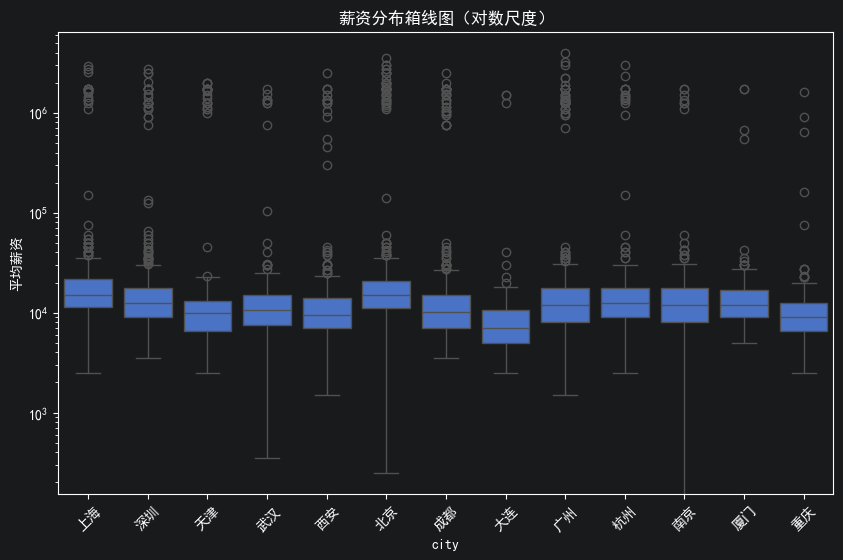

In [22]:
# 计算每个城市的薪资分布
salary_distribution_by_city = data.groupby('city')['平均薪资'].describe()

# 使用 seaborn 创建箱线图
plt.figure(figsize=(10, 6))  # 设置图表大小
sns.boxplot(x='city', y='平均薪资', data=data)
plt.yscale('log')  # 使用对数尺度
plt.xticks(rotation=45)  # 旋转 x 轴标签，避免重叠
plt.title('薪资分布箱线图（对数尺度）')
plt.show()

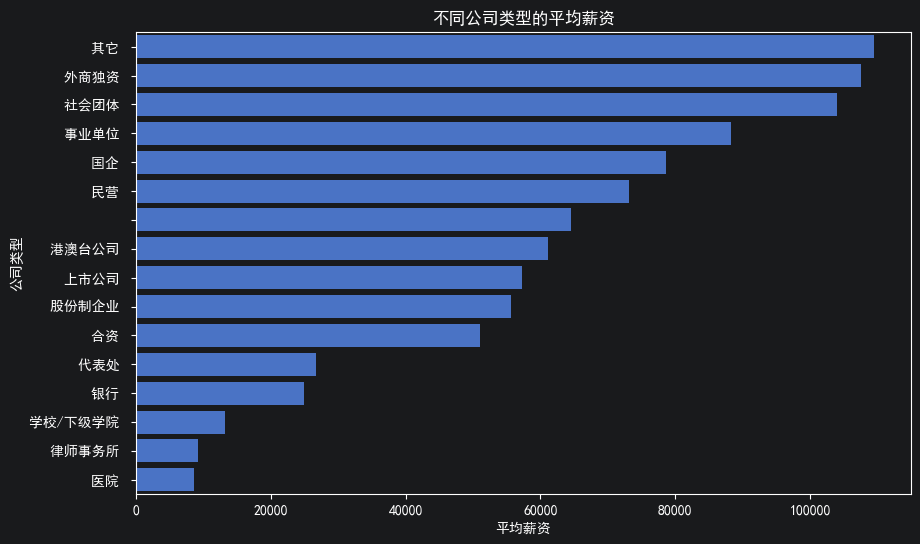

In [23]:
average_salary_by_industry = data.groupby('公司类型')['平均薪资'].mean().sort_values(ascending=False)

# 使用 seaborn 创建条形图
plt.figure(figsize=(10, 6))  # 设置图表大小
sns.barplot(x=average_salary_by_industry.values, y=average_salary_by_industry.index)
plt.xlabel('平均薪资')
plt.title('不同公司类型的平均薪资')
plt.show()

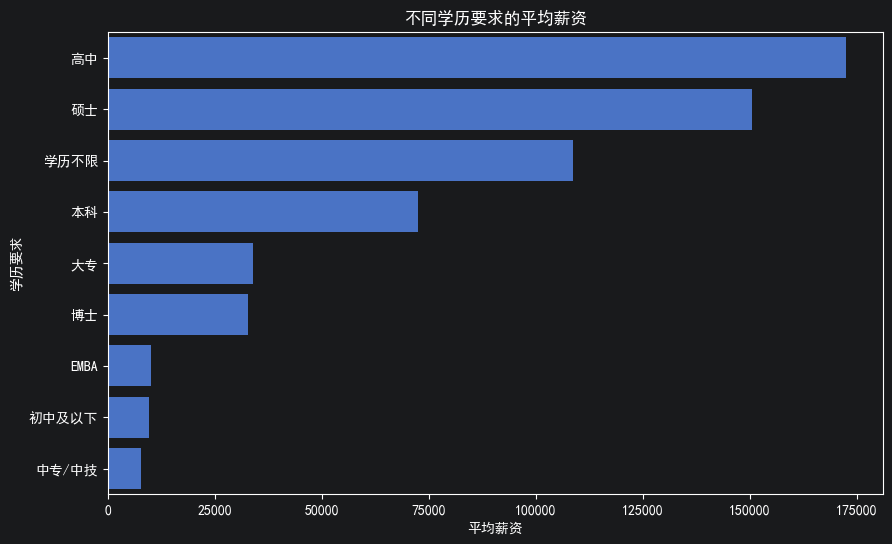

In [24]:
average_salary_by_education = data.groupby('学历要求')['平均薪资'].mean().sort_values(ascending=False)
# 使用 seaborn 创建条形图
plt.figure(figsize=(10, 6))  # 设置图表大小
sns.barplot(x=average_salary_by_education.values, y=average_salary_by_education.index)
plt.xlabel('平均薪资')
plt.title('不同学历要求的平均薪资')
plt.show()

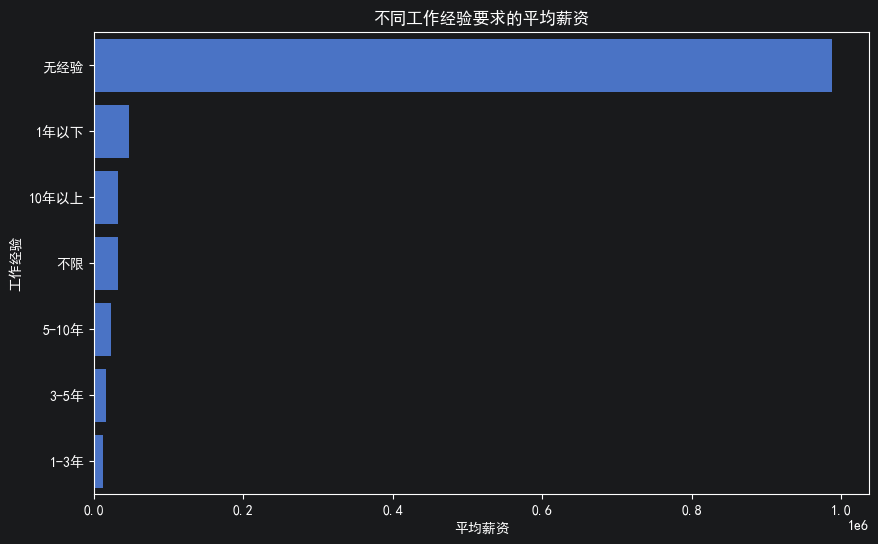

In [25]:
average_salary_by_experience = data.groupby('工作经验')['平均薪资'].mean().sort_values(ascending=False)
# 使用 seaborn 创建条形图
plt.figure(figsize=(10, 6))  # 设置图表大小
sns.barplot(x=average_salary_by_experience.values, y=average_salary_by_experience.index)
plt.xlabel('平均薪资')
plt.title('不同工作经验要求的平均薪资')
plt.show()